# MNIST MLP3 — old vs horizon-optimized comparison

Compares old SGD, old AdamW, old Muon, new AdamW, and new Muon with final metrics, validation-loss-selected metrics, matched-seed contrasts, convergence, full plots, zoomed plots, and WeightWatcher spectral diagnostics.

In [1]:
from pathlib import Path
import json
import math
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from rg_baselines import DEFAULT_BASELINE_SEEDS, MNIST_REFERENCE_INITIALIZATION, MNIST_REFERENCE_RECIPE_VERSION, MNIST_REFERENCE_SUITE_SLUG
from rg_baselines.statistics import student_t_critical_95
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
BASE_RUN_ROOT = Path(os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
OUTPUT_DIR = RUN_ROOT / 'horizon_optimized_comparison'
PLOT_DIR = OUTPUT_DIR / 'plots'
ZOOM_DIR = PLOT_DIR / 'zoomed'
for directory in (OUTPUT_DIR, PLOT_DIR, ZOOM_DIR):
    directory.mkdir(parents=True, exist_ok=True)
ARM_SPECS = [
    {'arm': 'old_sgd', 'label': 'old SGD + Nesterov', 'family': 'sgd_momentum', 'variant': 'old', 'directory': RUN_ROOT / 'sgd_momentum', 'color': '#0072B2', 'linestyle': '-'},
    {'arm': 'old_adamw', 'label': 'old AdamW', 'family': 'adamw', 'variant': 'old', 'directory': RUN_ROOT / 'adamw', 'color': '#D55E00', 'linestyle': ':'},
    {'arm': 'new_adamw', 'label': 'new AdamW, horizon optimized', 'family': 'adamw', 'variant': 'horizon_optimized', 'directory': RUN_ROOT / 'adamw_horizon_optimized', 'color': '#E69F00', 'linestyle': '-'},
    {'arm': 'old_muon', 'label': 'old Muon + aux AdamW', 'family': 'sgd_momentum_muon', 'variant': 'old', 'directory': RUN_ROOT / 'sgd_momentum_muon', 'color': '#009E73', 'linestyle': ':'},
    {'arm': 'new_muon', 'label': 'new Muon, horizon optimized', 'family': 'sgd_momentum_muon', 'variant': 'horizon_optimized', 'directory': RUN_ROOT / 'sgd_momentum_muon_horizon_optimized', 'color': '#56B4E9', 'linestyle': '-'},
]
ARM_ORDER = tuple(spec['arm'] for spec in ARM_SPECS)
ARM_LABELS = {spec['arm']: spec['label'] for spec in ARM_SPECS}
SEEDS = tuple(DEFAULT_BASELINE_SEEDS)
LAYER_ORDER = ('fc1', 'fc2', 'fc3')
print('versioned suite root:', RUN_ROOT)
display(pd.DataFrame(ARM_SPECS).drop(columns=['color', 'linestyle']))


versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3


,arm,label,family,variant,directory
0,old_sgd,old SGD + Nesterov,sgd_momentum,old,/private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/sgd_momentum
1,old_adamw,old AdamW,adamw,old,/private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/adamw
2,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,/private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/adamw_horizon_optimized
3,old_muon,old Muon + aux AdamW,sgd_momentum_muon,old,/private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/sgd_momentum_muon
4,new_muon,"new Muon, horizon optimized",sgd_momentum_muon,horizon_optimized,/private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/sgd_momentum_muon_horizon_optimized


In [2]:
REQUIRED_FILES = ('performance_by_epoch_and_seed.csv', 'spectral_metrics_by_epoch_layer_and_seed.csv', 'replicate_manifest.json')
def load_arm(spec):
    directory = Path(spec['directory'])
    missing = [directory / name for name in REQUIRED_FILES if not (directory / name).is_file()]
    if missing:
        raise FileNotFoundError('Run the notebook for ' + spec['label'] + ' before comparison:' + chr(10) + chr(10).join(map(str, missing)))
    manifest = json.loads((directory / 'replicate_manifest.json').read_text(encoding='utf-8'))
    cfg = manifest['config_template']
    if cfg['recipe_version'] != MNIST_REFERENCE_RECIPE_VERSION or cfg['initialization'] != MNIST_REFERENCE_INITIALIZATION:
        raise RuntimeError('wrong recipe or initialization for ' + spec['label'])
    if tuple(int(seed) for seed in manifest['seeds']) != SEEDS:
        raise RuntimeError('seed tuple mismatch for ' + spec['label'])
    perf = pd.read_csv(directory / 'performance_by_epoch_and_seed.csv')
    specm = pd.read_csv(directory / 'spectral_metrics_by_epoch_layer_and_seed.csv')
    for frame in (perf, specm):
        frame.insert(0, 'arm', spec['arm'])
        frame.insert(1, 'arm_label', spec['label'])
        frame.insert(2, 'family', spec['family'])
        frame.insert(3, 'variant', spec['variant'])
    return manifest, perf, specm
manifests = {}
perf_frames = []
spec_frames = []
for spec in ARM_SPECS:
    manifest, perf, specm = load_arm(spec)
    manifests[spec['arm']] = manifest
    perf_frames.append(perf)
    spec_frames.append(specm)
performance = pd.concat(perf_frames, ignore_index=True, sort=False)
spectral_metrics = pd.concat(spec_frames, ignore_index=True, sort=False)
performance['test_perplexity'] = np.exp(performance['test_loss'].astype(float))
performance['validation_perplexity'] = np.exp(performance['validation_loss'].astype(float))
config_table = pd.DataFrame([{'arm': arm, 'arm_label': ARM_LABELS[arm], **manifest['config_template']} for arm, manifest in manifests.items()])
config_table.to_csv(OUTPUT_DIR / 'arm_configurations.csv', index=False)
display(config_table)
print('performance rows:', len(performance), 'spectral rows:', len(spectral_metrics))


,arm,arm_label,optimizer,recipe_version,initialization,seed,epochs,batch_size,validation_size,split_seed,num_workers,grad_clip_norm,train_eval_max_batches,schedule,checkpoint_every_epochs,test_monitoring_only,sgd_learning_rate,sgd_min_learning_rate,sgd_warmup_epochs,sgd_momentum,sgd_dampening,sgd_nesterov,sgd_weight_decay,adamw_learning_rate,adamw_min_learning_rate,adamw_warmup_epochs,adamw_beta1,adamw_beta2,adamw_eps,adamw_weight_decay,adamw_amsgrad,muon_parameter_names,muon_learning_rate,muon_min_learning_rate,muon_warmup_epochs,muon_momentum,muon_nesterov,muon_weight_decay,muon_newton_schulz_steps,muon_eps,muon_aux_learning_rate,muon_aux_min_learning_rate,muon_aux_beta1,muon_aux_beta2,muon_aux_eps,muon_aux_weight_decay,ww_min_evals,ww_max_evals,ww_svd_method,ww_randomize,save_epoch_checkpoints,strict_metrics
0,old_sgd,old SGD + Nesterov,sgd_momentum,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.0010,0.000010,1,0.9,0.999,1.000000e-08,0.01,False,"[fc1.weight, fc2.weight]",0.02,0.0020,2,0.95,True,0.01,5,1.000000e-07,0.0003,0.000030,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True
1,old_adamw,old AdamW,adamw,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.0010,0.000010,1,0.9,0.999,1.000000e-08,0.01,False,"[fc1.weight, fc2.weight]",0.02,0.0020,2,0.95,True,0.01,5,1.000000e-07,0.0003,0.000030,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True
2,new_adamw,"new AdamW, horizon optimized",adamw,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.0005,0.000001,2,0.9,0.999,1.000000e-08,0.03,False,"[fc1.weight, fc2.weight]",0.02,0.0020,2,0.95,True,0.01,5,1.000000e-07,0.0003,0.000030,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True
3,old_muon,old Muon + aux AdamW,sgd_momentum_muon,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.0010,0.000010,1,0.9,0.999,1.000000e-08,0.01,False,"[fc1.weight, fc2.weight]",0.02,0.0020,2,0.95,True,0.01,5,1.000000e-07,0.0003,0.000030,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True
4,new_muon,"new Muon, horizon optimized",sgd_momentum_muon,3,kaiming_uniform_relu_hidden_xavier_uniform_head_v1,1337,30,128,5000,20260807,0,1.0,None,warmup_cosine,1,True,0.05,0.0005,2,0.9,0.0,True,0.0001,0.0010,0.000010,1,0.9,0.999,1.000000e-08,0.01,False,"[fc1.weight, fc2.weight]",0.01,0.0002,2,0.95,True,0.02,5,1.000000e-07,0.0003,0.000003,0.9,0.95,1.000000e-08,0.01,8,None,accurate,True,True,True


performance rows: 465 spectral rows: 1395


In [3]:
def summarize(frame, groups, metrics):
    rows = []
    for keys, group in frame.groupby(list(groups), dropna=False, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        base = dict(zip(groups, keys, strict=True))
        for metric in metrics:
            if metric not in group.columns:
                continue
            values = pd.to_numeric(group[metric], errors='coerce').to_numpy(dtype=float)
            values = values[np.isfinite(values)]
            if len(values) == 0:
                continue
            n = int(len(values))
            mean = float(values.mean())
            std = float(values.std(ddof=1)) if n > 1 else 0.0
            sem = std / math.sqrt(n) if n > 1 else 0.0
            half = float(student_t_critical_95(n)) * sem if n > 1 else 0.0
            rows.append({**base, 'metric': metric, 'n': n, 'mean': mean, 'std': std, 'sem': sem, 'ci_half_width': half, 'ci_low': mean - half, 'ci_high': mean + half, 'minimum': float(values.min()), 'maximum': float(values.max())})
    return pd.DataFrame(rows)
PERF_METRICS = ['train_loss', 'validation_loss', 'test_loss', 'train_accuracy', 'validation_accuracy', 'test_accuracy', 'validation_loss_gap', 'test_loss_gap', 'validation_accuracy_gap', 'test_accuracy_gap', 'primary_lr', 'auxiliary_lr', 'parameter_l2_norm', 'mean_gradient_norm_before_clip', 'max_gradient_norm_before_clip']
performance_summary = summarize(performance, ('arm', 'arm_label', 'family', 'variant', 'epoch'), PERF_METRICS)
def terminal_rows(frame):
    rows = []
    for (arm, seed), run in frame.groupby(['arm', 'seed'], sort=True):
        ordered = run.sort_values('epoch')
        final = ordered.iloc[-1].copy()
        final['checkpoint'] = 'final'
        rows.append(final)
        selected = ordered.sort_values(['validation_loss', 'epoch'], ascending=[True, True]).iloc[0].copy()
        selected['checkpoint'] = 'validation_selected'
        rows.append(selected)
    return pd.DataFrame(rows).reset_index(drop=True)
terminal_by_seed = terminal_rows(performance)
terminal_summary = summarize(terminal_by_seed, ('arm', 'arm_label', 'family', 'variant', 'checkpoint'), PERF_METRICS)
terminal_by_seed.to_csv(OUTPUT_DIR / 'terminal_by_seed.csv', index=False)
terminal_summary.to_csv(OUTPUT_DIR / 'terminal_summary_95ci.csv', index=False)
display(terminal_by_seed.sort_values(['checkpoint', 'family', 'variant', 'seed']))
display(terminal_summary[terminal_summary['metric'].isin(['test_accuracy', 'test_loss', 'validation_loss', 'parameter_l2_norm'])].sort_values(['checkpoint', 'metric', 'family', 'variant']))


,arm,arm_label,family,variant,run,optimizer,epoch,global_step,primary_lr,auxiliary_lr,train_loss,train_accuracy,train_examples_evaluated,validation_loss,validation_accuracy,validation_examples_evaluated,test_loss,test_accuracy,test_examples_evaluated,validation_loss_gap,test_loss_gap,validation_accuracy_gap,test_accuracy_gap,test_monitoring_only,online_train_loss,online_train_accuracy,mean_gradient_norm_before_clip,median_gradient_norm_before_clip,max_gradient_norm_before_clip,batches,parameter_l2_norm,train_time_sec,evaluation_time_sec,weightwatcher_time_sec,epoch_total_time_sec,device,seed,replicate,optimizer_label,test_perplexity,validation_perplexity,checkpoint
0,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,AdamW,adamw,30,12900,0.000001,NaN,4.118918e-05,1.000000,55000,0.078369,0.9858,5000,0.073215,0.9847,10000,0.078327,0.073174,0.014200,0.015300,1,4.148644e-05,1.000000,2.015467e-03,1.786184e-03,1.066747e-02,430,46.695293,4.962602,5.099074,2.999262,13.060938,mps,1337,0,AdamW,1.075962,1.081521,final
2,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,AdamW,adamw,30,12900,0.000001,NaN,4.296827e-05,1.000000,55000,0.084605,0.9848,5000,0.077209,0.9835,10000,0.084562,0.077166,0.015200,0.016500,1,4.324695e-05,1.000000,2.086195e-03,1.809056e-03,8.169408e-03,430,47.003891,5.023732,5.321210,3.959844,14.304786,mps,2027,1,AdamW,1.080268,1.088287,final
4,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,AdamW,adamw,30,12900,0.000001,NaN,4.683341e-05,1.000000,55000,0.077309,0.9860,5000,0.072550,0.9843,10000,0.077262,0.072503,0.014000,0.015700,1,4.712047e-05,1.000000,2.306453e-03,2.067188e-03,1.120685e-02,430,46.984495,4.537570,4.570533,2.879350,11.987453,mps,31415,2,AdamW,1.075246,1.080376,final
12,old_adamw,old AdamW,adamw,old,AdamW,adamw,30,12900,0.000010,NaN,1.468589e-05,1.000000,55000,0.087420,0.9858,5000,0.077554,0.9852,10000,0.087406,0.077540,0.014200,0.014800,1,1.497354e-05,1.000000,7.106780e-04,5.965125e-04,4.089085e-03,430,57.086986,4.533634,4.454976,2.531176,11.519786,mps,1337,0,AdamW,1.080641,1.091355,final
14,old_adamw,old AdamW,adamw,old,AdamW,adamw,30,12900,0.000010,NaN,1.581340e-05,1.000000,55000,0.084746,0.9868,5000,0.084766,0.9855,10000,0.084730,0.084750,0.013200,0.014500,1,1.611085e-05,1.000000,7.548133e-04,6.386511e-04,3.509696e-03,430,57.505001,4.586236,4.534660,2.700541,11.821437,mps,2027,1,AdamW,1.088462,1.088440,final
16,old_adamw,old AdamW,adamw,old,AdamW,adamw,30,12900,0.000010,NaN,1.408119e-05,1.000000,55000,0.093397,0.9866,5000,0.085351,0.9847,10000,0.093383,0.085337,0.013400,0.015300,1,1.436087e-05,1.000000,6.935033e-04,5.724836e-04,6.499063e-03,430,57.158256,4.536428,4.520927,7.431150,16.488505,mps,31415,2,AdamW,1.089100,1.097897,final
24,old_sgd,old SGD + Nesterov,sgd_momentum,old,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.801713e-04,1.000000,55000,0.061781,0.9846,5000,0.059031,0.9841,10000,0.061101,0.058351,0.015400,0.015900,1,6.813720e-04,1.000000,2.169779e-02,1.987243e-02,6.311906e-02,430,35.853322,4.329755,4.549400,3.660399,12.539553,mps,1337,0,SGD + Nesterov momentum,1.060808,1.063729,final
26,old_sgd,old SGD + Nesterov,sgd_momentum,old,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.902663e-04,1.000000,55000,0.060265,0.9852,5000,0.055548,0.9848,10000,0.059575,0.054858,0.014800,0.015200,1,6.915217e-04,1.000000,2.195937e-02,2.086831e-02,6.582585e-02,430,35.916103,4.326884,4.640553,2.583035,11.550472,mps,2027,1,SGD + Nesterov momentum,1.057120,1.062118,final
28,old_sgd,old SGD + Nesterov,sgd_momentum,old,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.679502e-04,1.000000,55000,0.056884,0.9862,5000,0.055936,0.9836,10000,0.056216,0.055268,0.013800,0.016400,1,6.691356e-04,1.000000,2.131569e-02,2.023451e-02,8.055064e-02,430,35.897569,4.595391,5.008348,3.166980,12.770719,mps,31415,2,SGD + Nesterov momentum,1.057530,1.058533,final
6,new_muon,"new Muon, horizon optimized",sgd_momentum_muon,horizon_optimized,Muon + auxil

,arm,arm_label,family,variant,checkpoint,metric,n,mean,std,sem,ci_half_width,ci_low,ci_high,minimum,maximum
11,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,final,parameter_l2_norm,3,46.894560,0.172842,0.099791,0.429364,46.465196,47.323924,46.695293,47.003891
69,old_adamw,old AdamW,adamw,old,final,parameter_l2_norm,3,57.250081,0.223624,0.129110,0.555514,56.694567,57.805595,57.086986,57.505001
127,old_sgd,old SGD + Nesterov,sgd_momentum,old,final,parameter_l2_norm,3,35.888998,0.032256,0.018623,0.080128,35.808870,35.969127,35.853322,35.916103
40,new_muon,"new Muon, horizon optimized",sgd_momentum_muon,horizon_optimized,final,parameter_l2_norm,3,50.934132,0.371125,0.214269,0.921927,50.012205,51.856059,50.507639,51.183601
98,old_muon,old Muon + aux AdamW,sgd_momentum_muon,old,final,parameter_l2_norm,3,85.105450,0.189903,0.109640,0.471745,84.633706,85.577195,84.935265,85.310296
5,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,final,test_accuracy,3,0.984167,0.000611,0.000353,0.001518,0.982649,0.985684,0.983500,0.984700
63,old_adamw,old AdamW,adamw,old,final,test_accuracy,3,0.985133,0.000404,0.000233,0.001004,0.984129,0.986137,0.984700,0.985500
121,old_sgd,old SGD + Nesterov,sgd_momentum,old,final,test_accuracy,3,0.984167,0.000603,0.000348,0.001497,0.982669,0.985664,0.983600,0.984800
33,new_muon,"new Muon, horizon optimized",sgd_momentum_muon,horizon_optimized,final,test_accuracy,3,0.986467,0.000666,0.000384,0.001654,0.984813,0.988121,0.985700,0.986900
91,old_muon,old Muon + aux AdamW,sgd_momentum_muon,old,final,test_accuracy,3,0.986333,0.000681,0.000393,0.001691,0.984642,0.988024,0.985800,0.987100


In [4]:
def metric_row(summary, arm, checkpoint, metric):
    rows = summary.loc[summary['arm'].eq(arm) & summary['checkpoint'].eq(checkpoint) & summary['metric'].eq(metric)]
    if rows.empty:
        raise KeyError((arm, checkpoint, metric))
    return rows.iloc[0]
rank_specs = [('final', 'test_accuracy', 'max'), ('final', 'test_loss', 'min'), ('validation_selected', 'test_accuracy', 'max'), ('validation_selected', 'test_loss', 'min'), ('validation_selected', 'validation_loss', 'min')]
rank_rows = []
for checkpoint, metric, direction in rank_specs:
    vals = []
    for arm in ARM_ORDER:
        row = metric_row(terminal_summary, arm, checkpoint, metric)
        vals.append((arm, float(row['mean']), float(row['ci_half_width'])))
    vals.sort(key=lambda item: item[1], reverse=(direction == 'max'))
    for rank, (arm, mean, half) in enumerate(vals, start=1):
        rank_rows.append({'checkpoint': checkpoint, 'metric': metric, 'direction': direction, 'rank': rank, 'arm': arm, 'arm_label': ARM_LABELS[arm], 'mean': mean, 'ci_half_width': half})
rank_table = pd.DataFrame(rank_rows)
display(rank_table)


,checkpoint,metric,direction,rank,arm,arm_label,mean,ci_half_width
0,final,test_accuracy,max,1,new_muon,"new Muon, horizon optimized",0.986467,0.001654
1,final,test_accuracy,max,2,old_muon,old Muon + aux AdamW,0.986333,0.001691
2,final,test_accuracy,max,3,old_adamw,old AdamW,0.985133,0.001004
3,final,test_accuracy,max,4,old_sgd,old SGD + Nesterov,0.984167,0.001497
4,final,test_accuracy,max,5,new_adamw,"new AdamW, horizon optimized",0.984167,0.001518
5,final,test_loss,min,1,old_sgd,old SGD + Nesterov,0.056838,0.004742
6,final,test_loss,min,2,new_adamw,"new AdamW, horizon optimized",0.074325,0.006260
7,final,test_loss,min,3,old_adamw,old AdamW,0.082557,0.010787
8,final,test_loss,min,4,new_muon,"new Muon, horizon optimized",0.091211,0.013167
9,final,test_loss,min,5,old_muon,old Muon + aux AdamW,0.123379,0.008896


In [5]:
PAIR_METRICS = ['test_accuracy', 'test_loss', 'validation_loss', 'parameter_l2_norm']
CONTRASTS = [('new_adamw', 'old_adamw'), ('new_muon', 'old_muon'), ('new_adamw', 'old_sgd'), ('new_muon', 'old_sgd'), ('new_muon', 'new_adamw')]
rows = []
for checkpoint in ('final', 'validation_selected'):
    selected = terminal_by_seed.loc[terminal_by_seed['checkpoint'].eq(checkpoint)]
    for arm_a, arm_b in CONTRASTS:
        for metric in PAIR_METRICS:
            a = selected.loc[selected['arm'].eq(arm_a), ['seed', metric]].rename(columns={metric: 'value_a'})
            b = selected.loc[selected['arm'].eq(arm_b), ['seed', metric]].rename(columns={metric: 'value_b'})
            paired = a.merge(b, on='seed', validate='one_to_one').sort_values('seed')
            values = (paired['value_a'] - paired['value_b']).to_numpy(dtype=float)
            n = len(values)
            mean = float(values.mean())
            std = float(values.std(ddof=1)) if n > 1 else 0.0
            half = float(student_t_critical_95(n)) * std / math.sqrt(n) if n > 1 else 0.0
            rows.append({'checkpoint': checkpoint, 'contrast': ARM_LABELS[arm_a] + ' - ' + ARM_LABELS[arm_b], 'metric': metric, 'n': n, 'mean_difference': mean, 'ci_half_width': half, 'ci_low': mean - half, 'ci_high': mean + half})
paired_differences = pd.DataFrame(rows)
paired_differences.to_csv(OUTPUT_DIR / 'paired_old_new_differences_95ci.csv', index=False)
display(paired_differences.sort_values(['checkpoint', 'metric', 'contrast']))


,checkpoint,contrast,metric,n,mean_difference,ci_half_width,ci_low,ci_high
3,final,"new AdamW, horizon optimized - old AdamW",parameter_l2_norm,3,-10.355521,0.413969,-10.769490,-9.941552
11,final,"new AdamW, horizon optimized - old SGD + Nesterov",parameter_l2_norm,3,11.005562,0.351939,10.653623,11.357501
19,final,"new Muon, horizon optimized - new AdamW, horizon optimized",parameter_l2_norm,3,4.039572,0.493258,3.546314,4.532830
7,final,"new Muon, horizon optimized - old Muon + aux AdamW",parameter_l2_norm,3,-34.171319,1.382561,-35.553879,-32.788758
15,final,"new Muon, horizon optimized - old SGD + Nesterov",parameter_l2_norm,3,15.045133,0.843437,14.201696,15.888570
0,final,"new AdamW, horizon optimized - old AdamW",test_accuracy,3,-0.000967,0.002227,-0.003193,0.001260
8,final,"new AdamW, horizon optimized - old SGD + Nesterov",test_accuracy,3,0.000000,0.002799,-0.002799,0.002799
16,final,"new Muon, horizon optimized - new AdamW, horizon optimized",test_accuracy,3,0.002300,0.000657,0.001643,0.002957
4,final,"new Muon, horizon optimized - old Muon + aux AdamW",test_accuracy,3,0.000133,0.001456,-0.001322,0.001589
12,final,"new Muon, horizon optimized - old SGD + Nesterov",test_accuracy,3,0.002300,0.003103,-0.000803,0.005403


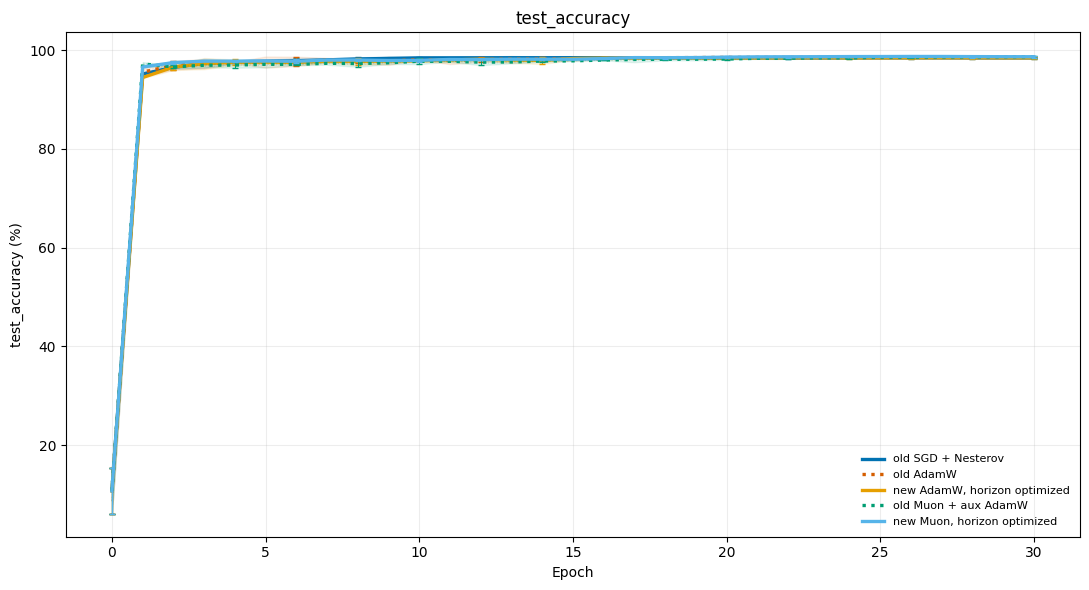

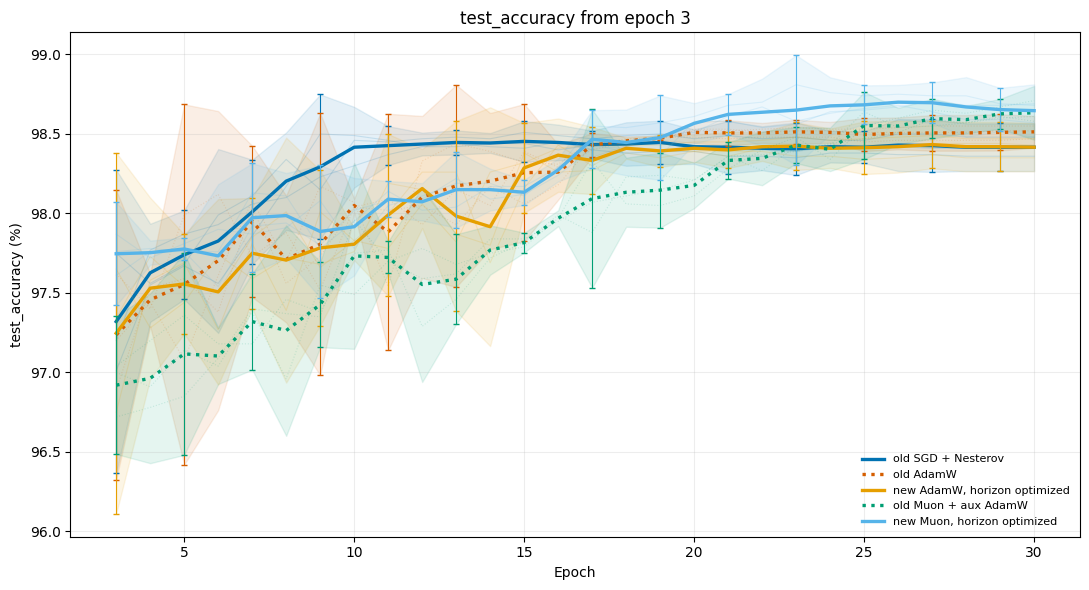

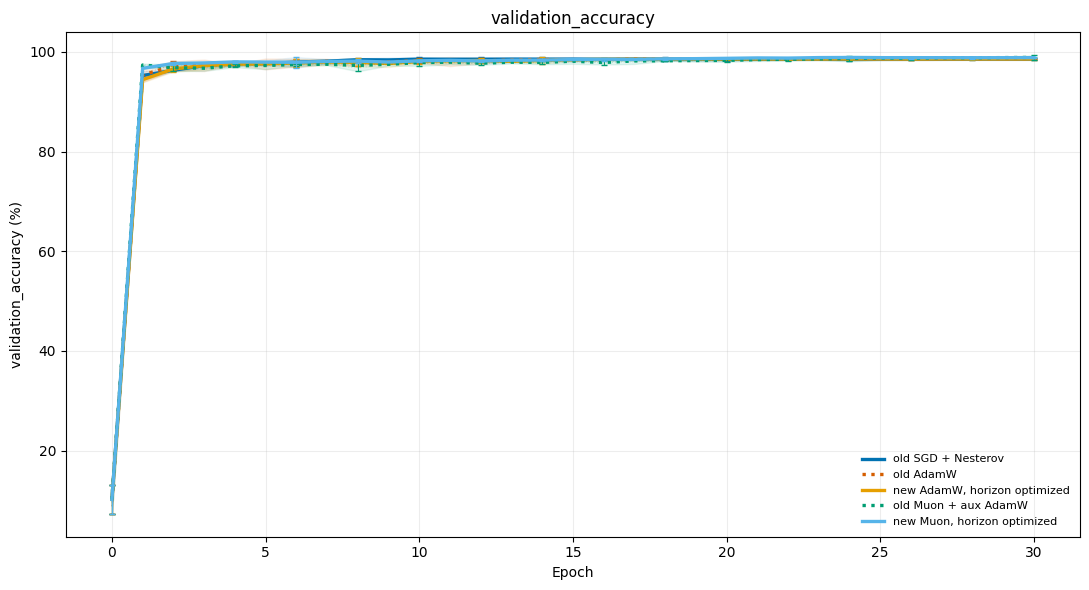

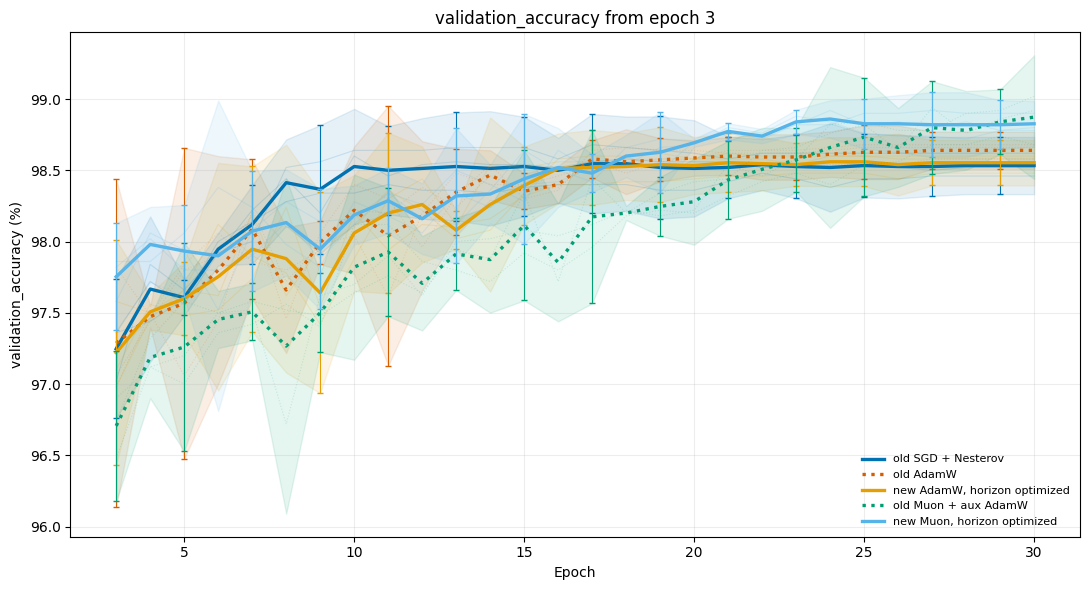

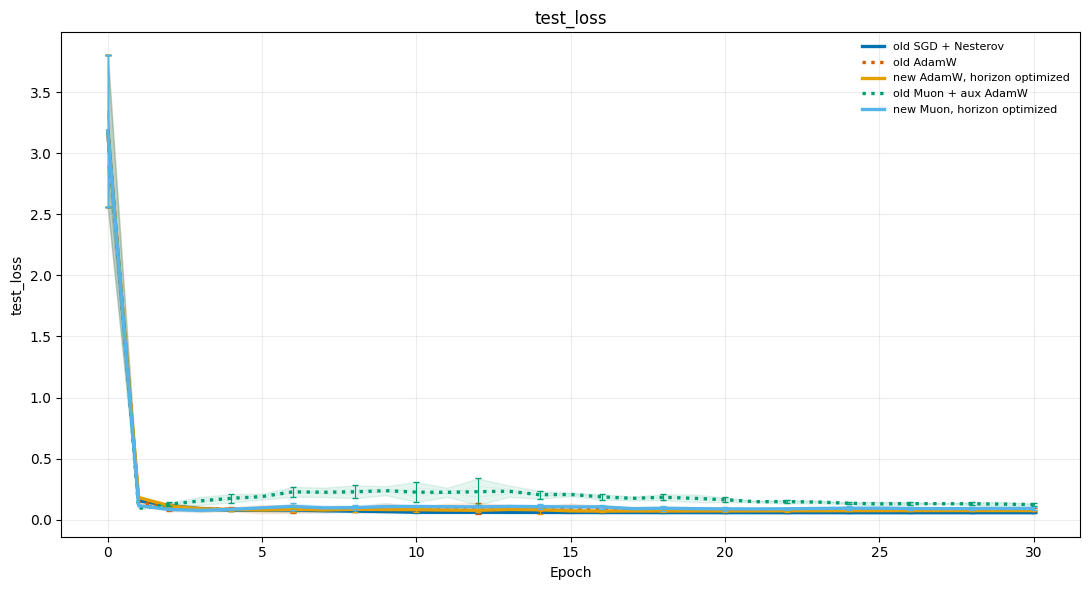

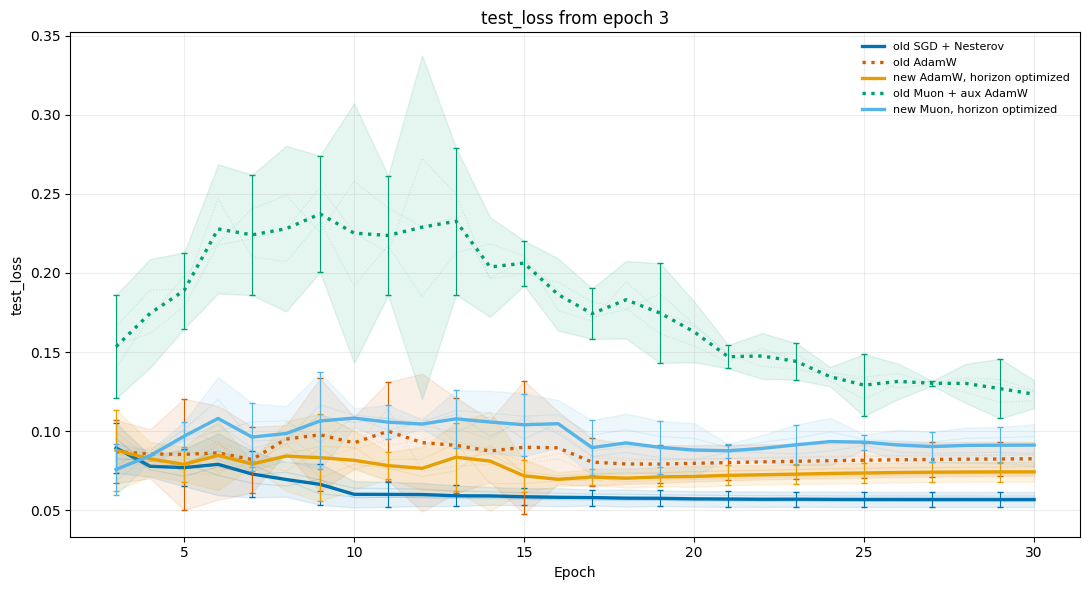

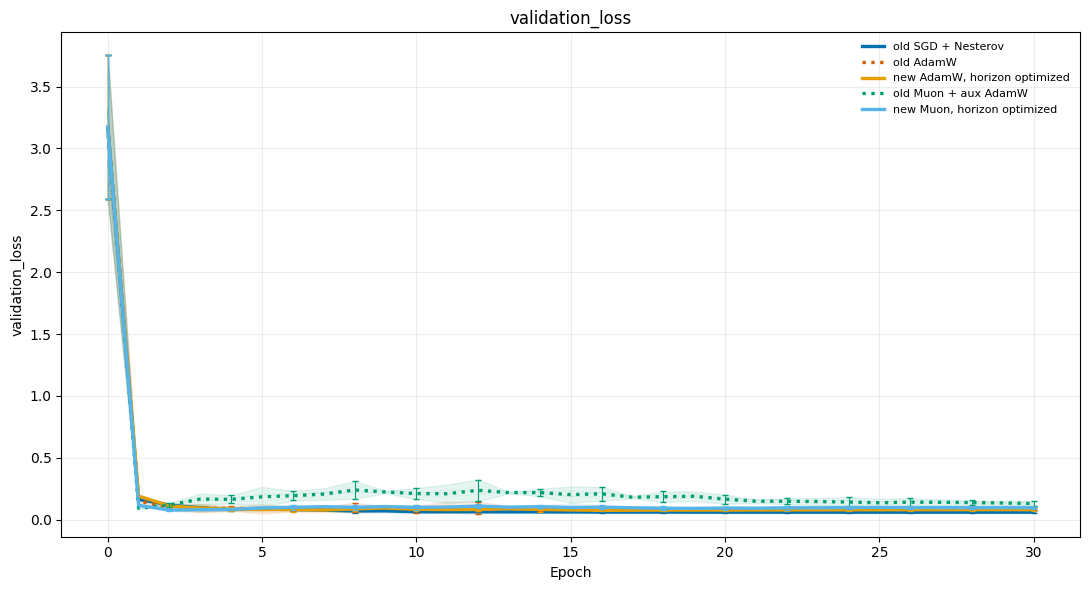

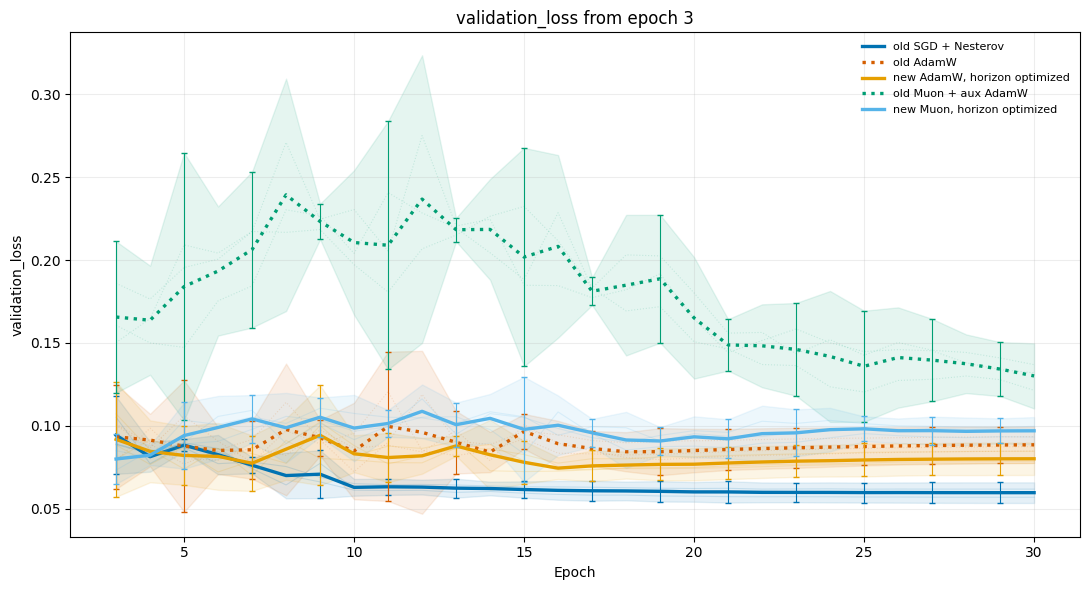

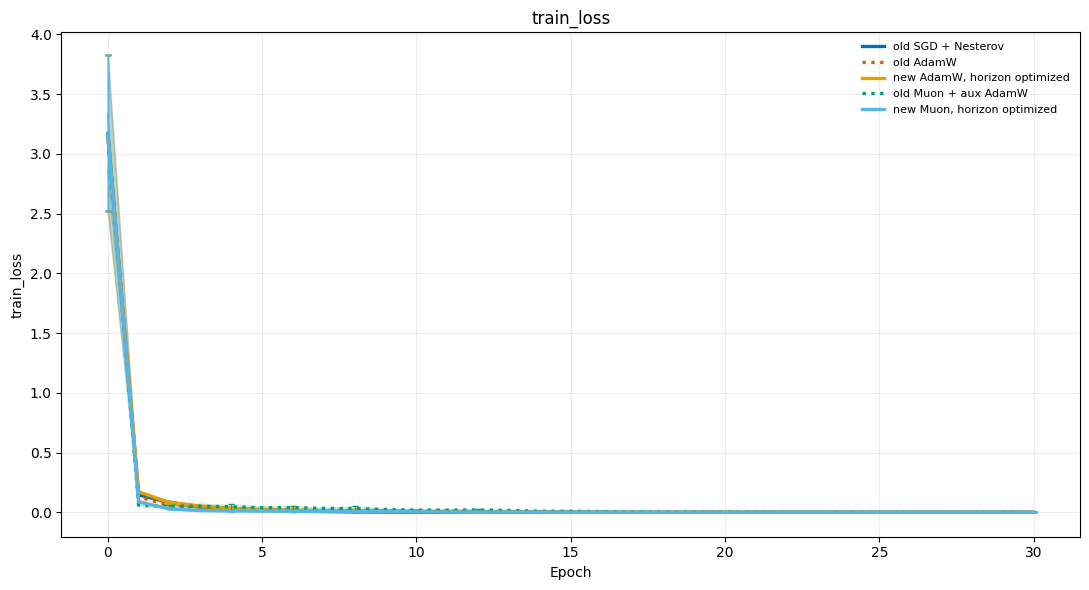

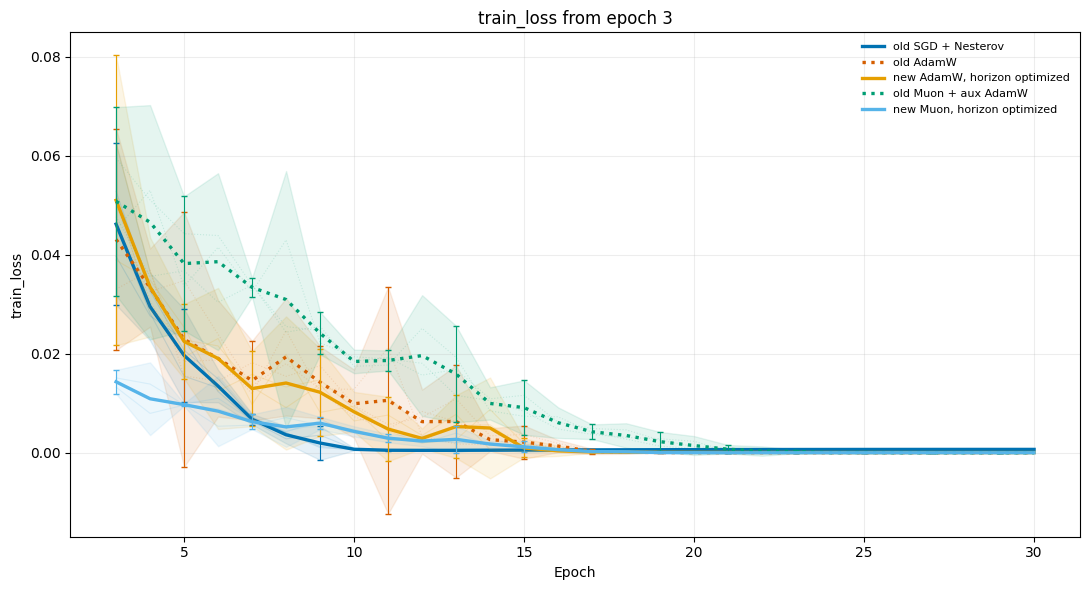

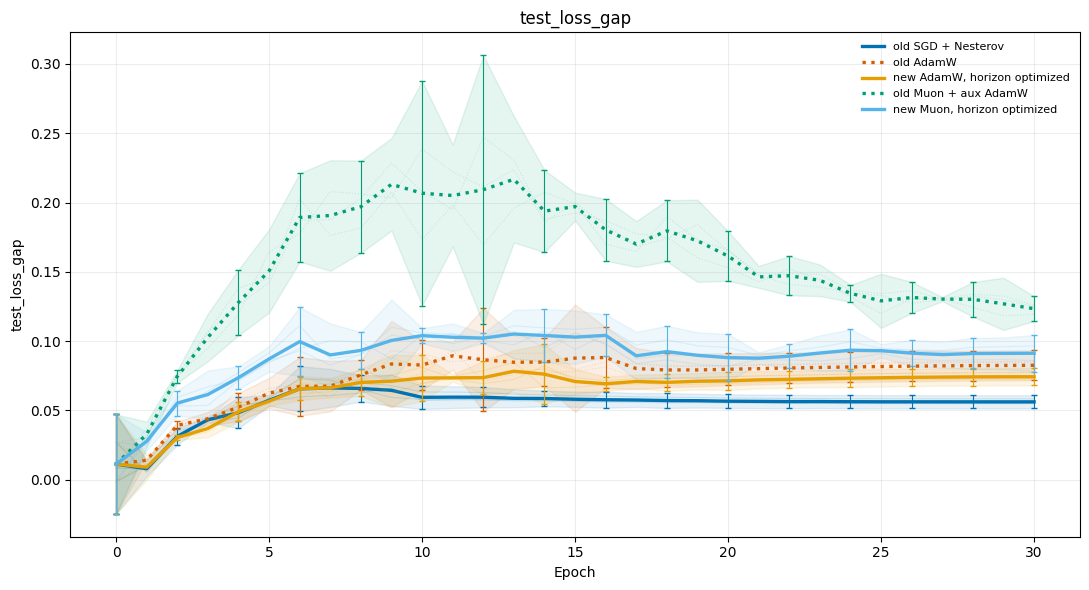

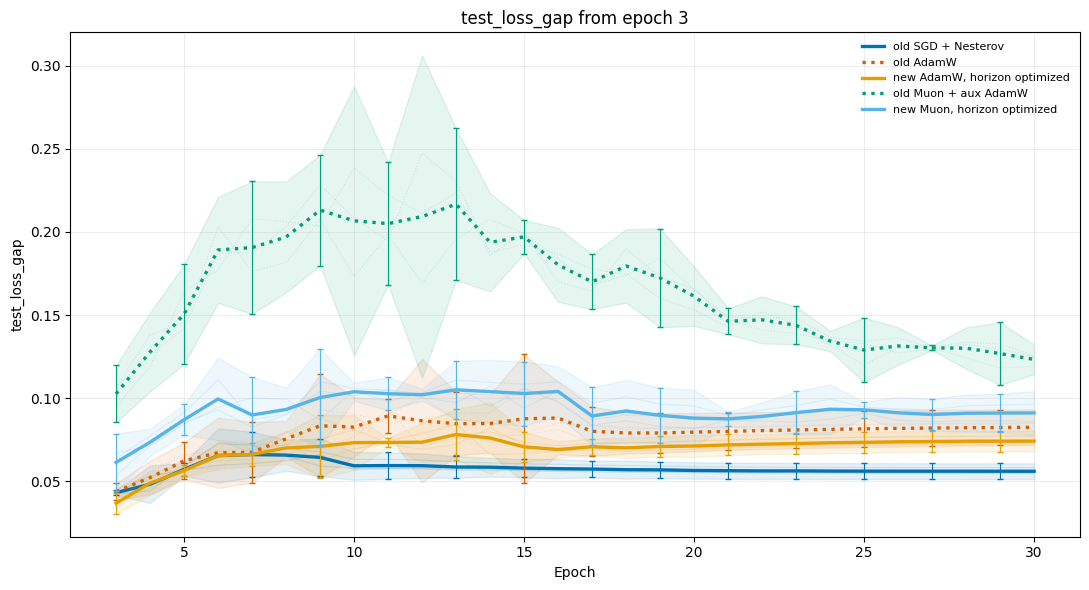

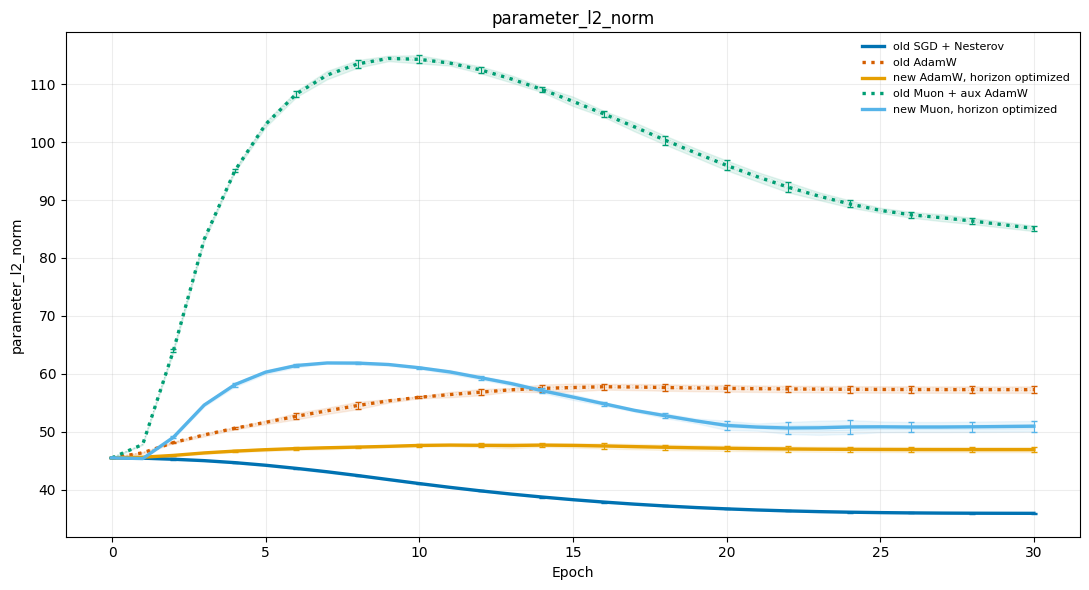

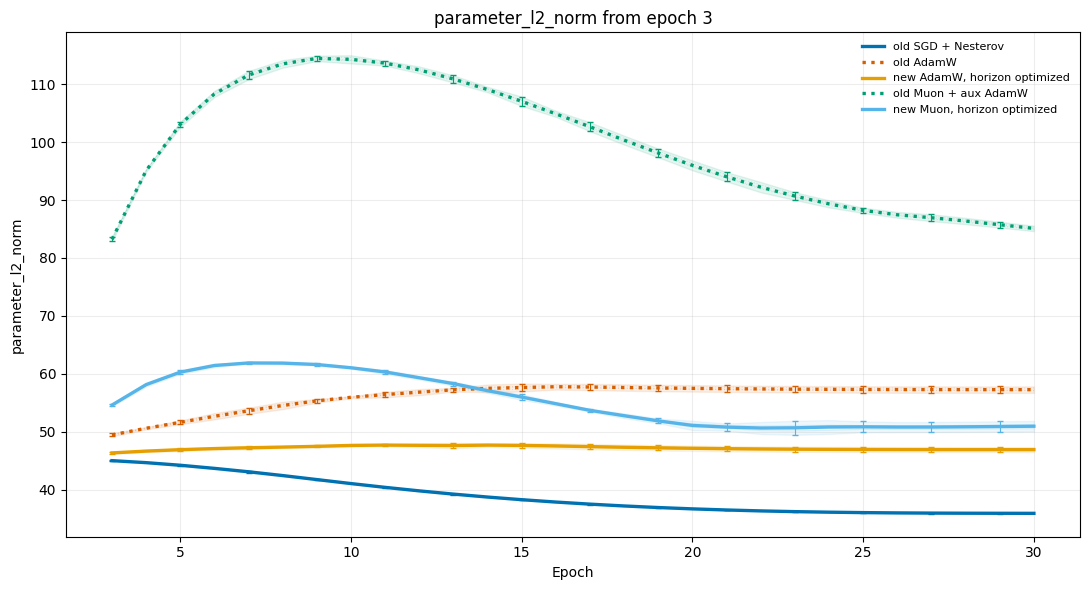

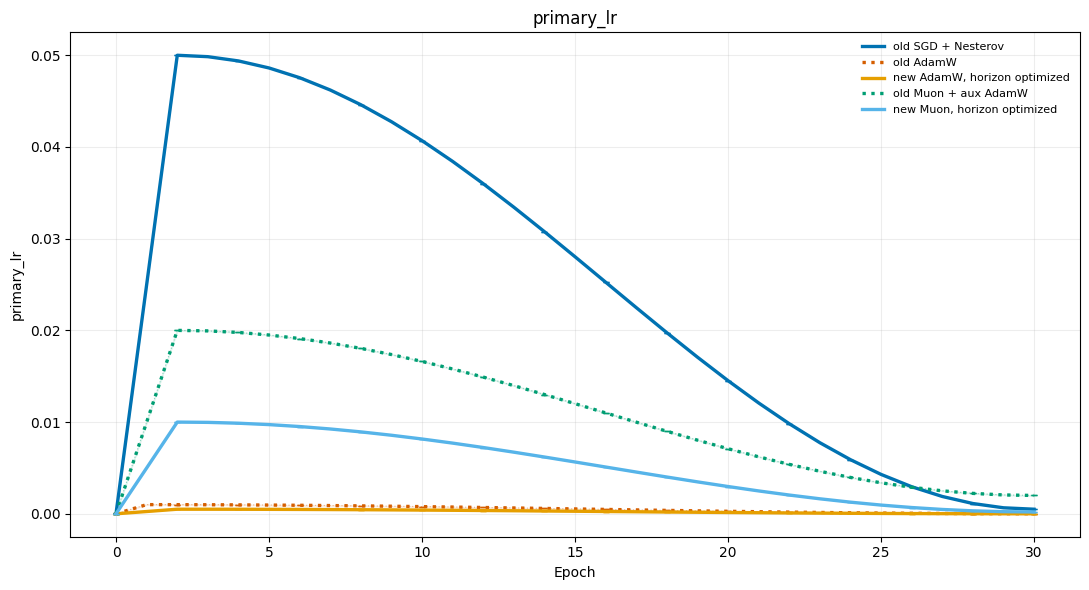

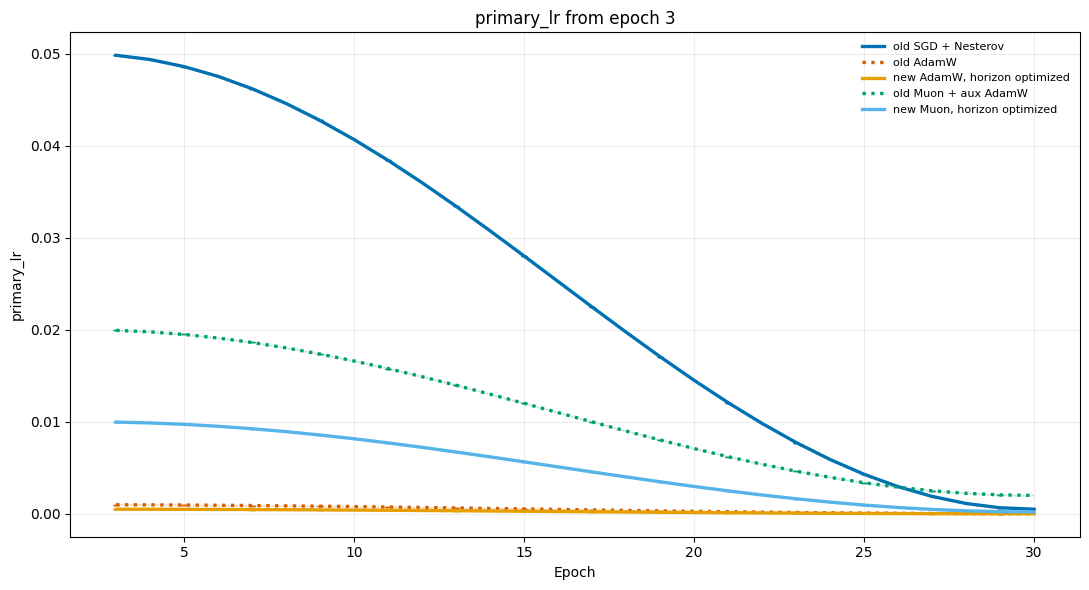

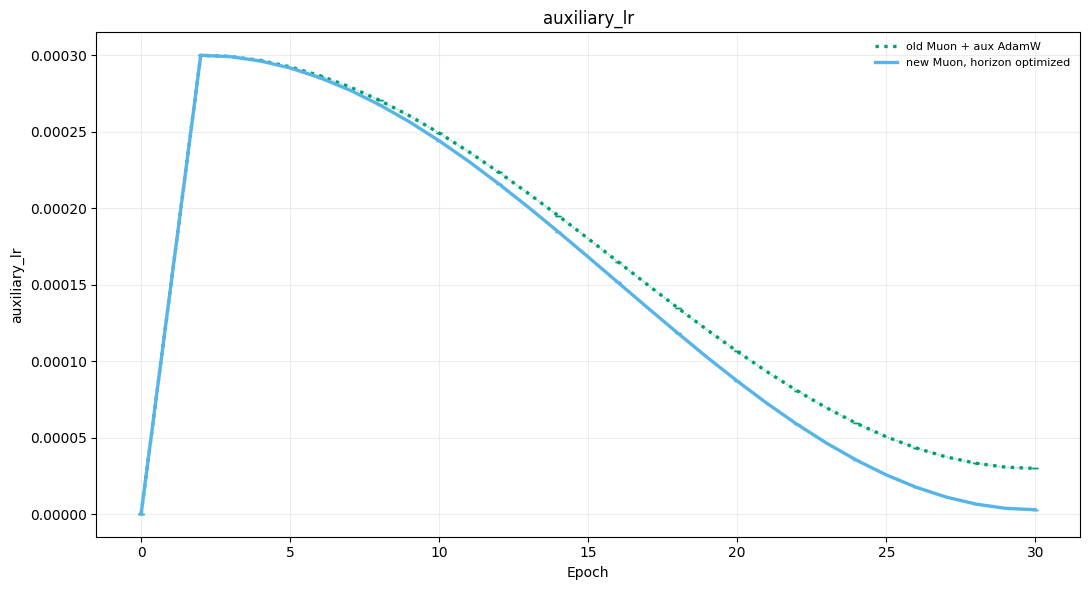

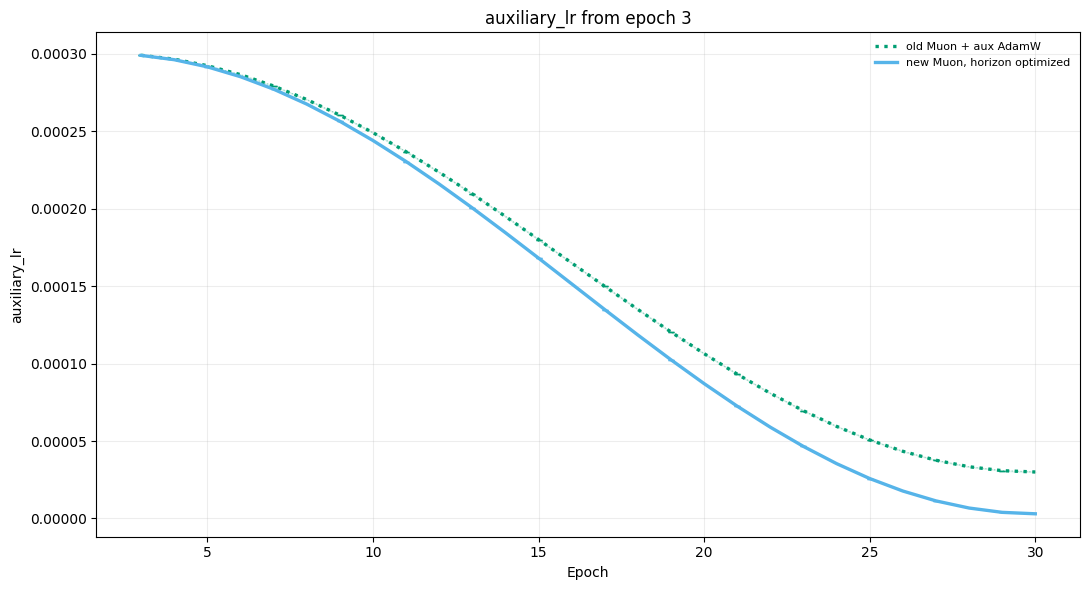

In [6]:
def plot_perf(metric, percent=False, zoom_start=None):
    data = performance.copy()
    summary = performance_summary.copy()
    if zoom_start is not None:
        data = data.loc[data['epoch'].astype(int).ge(zoom_start)]
        summary = summary.loc[summary['epoch'].astype(int).ge(zoom_start)]
    fig, ax = plt.subplots(figsize=(11, 6))
    for spec in ARM_SPECS:
        raw = data.loc[data['arm'].eq(spec['arm'])]
        for seed, run in raw.groupby('seed'):
            values = pd.to_numeric(run[metric], errors='coerce').to_numpy(dtype=float)
            if percent:
                values = 100.0 * values
            ax.plot(run['epoch'], values, color=spec['color'], linestyle=spec['linestyle'], linewidth=0.8, alpha=0.15)
        rows = summary.loc[summary['arm'].eq(spec['arm']) & summary['metric'].eq(metric)].sort_values('epoch')
        if rows.empty:
            continue
        x = rows['epoch'].astype(float).to_numpy()
        mean = rows['mean'].astype(float).to_numpy()
        low = rows['ci_low'].astype(float).to_numpy()
        high = rows['ci_high'].astype(float).to_numpy()
        half = rows['ci_half_width'].astype(float).to_numpy()
        if percent:
            mean, low, high, half = [100.0 * v for v in (mean, low, high, half)]
        ax.plot(x, mean, color=spec['color'], linestyle=spec['linestyle'], linewidth=2.4, label=spec['label'])
        ax.fill_between(x, low, high, color=spec['color'], alpha=0.10)
        step = max(1, len(x) // 12)
        ax.errorbar(x[::step], mean[::step], yerr=half[::step], fmt='none', ecolor=spec['color'], elinewidth=0.8, capsize=2.0)
    ax.set(xlabel='Epoch', ylabel=metric + (' (%)' if percent else ''), title=metric if zoom_start is None else f'{metric} from epoch {zoom_start}')
    ax.grid(alpha=0.22)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    out = (ZOOM_DIR if zoom_start is not None else PLOT_DIR) / ((f'zoom_epoch{zoom_start}_' if zoom_start is not None else 'full_') + metric + '.png')
    fig.savefig(out, dpi=180, bbox_inches='tight')
    plt.show()
for metric, percent in [('test_accuracy', True), ('validation_accuracy', True), ('test_loss', False), ('validation_loss', False), ('train_loss', False), ('test_loss_gap', False), ('parameter_l2_norm', False), ('primary_lr', False), ('auxiliary_lr', False)]:
    if metric in performance.columns and performance[metric].notna().any():
        plot_perf(metric, percent=percent)
        plot_perf(metric, percent=percent, zoom_start=3)


,arm,arm_label,family,variant,layer,epoch,metric,n,mean,std,sem,ci_half_width,ci_low,ci_high,minimum,maximum
2,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,68.767704,288.898962,426.434371,332.000000,387.000000
8,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,1,ERG_gap,3,369.666667,20.502032,11.836854,50.929872,318.736795,420.596539,346.000000,382.000000
14,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,2,ERG_gap,3,374.333333,7.767453,4.484541,19.295424,355.037909,393.628757,368.000000,383.000000
20,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,3,ERG_gap,3,364.000000,4.582576,2.645751,11.383749,352.616251,375.383749,359.000000,368.000000
26,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,4,ERG_gap,3,350.333333,4.163332,2.403701,10.342290,339.991043,360.675623,347.000000,355.000000
32,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,5,ERG_gap,3,341.000000,5.196152,3.000000,12.907958,328.092042,353.907958,335.000000,344.000000
38,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,6,ERG_gap,3,331.666667,4.932883,2.848001,12.253960,319.412706,343.920627,326.000000,335.000000
44,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,7,ERG_gap,3,327.000000,7.810250,4.509250,19.401736,307.598264,346.401736,318.000000,332.000000
50,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,8,ERG_gap,3,322.333333,2.081666,1.201850,5.171145,317.162188,327.504478,320.000000,324.000000
56,new_adamw,"new AdamW, horizon optimized",adamw,horizon_optimized,fc1,9,ERG_gap,3,315.333333,1.154701,0.666667,2.868435,312.464898,318.201768,314.000000,316.000000


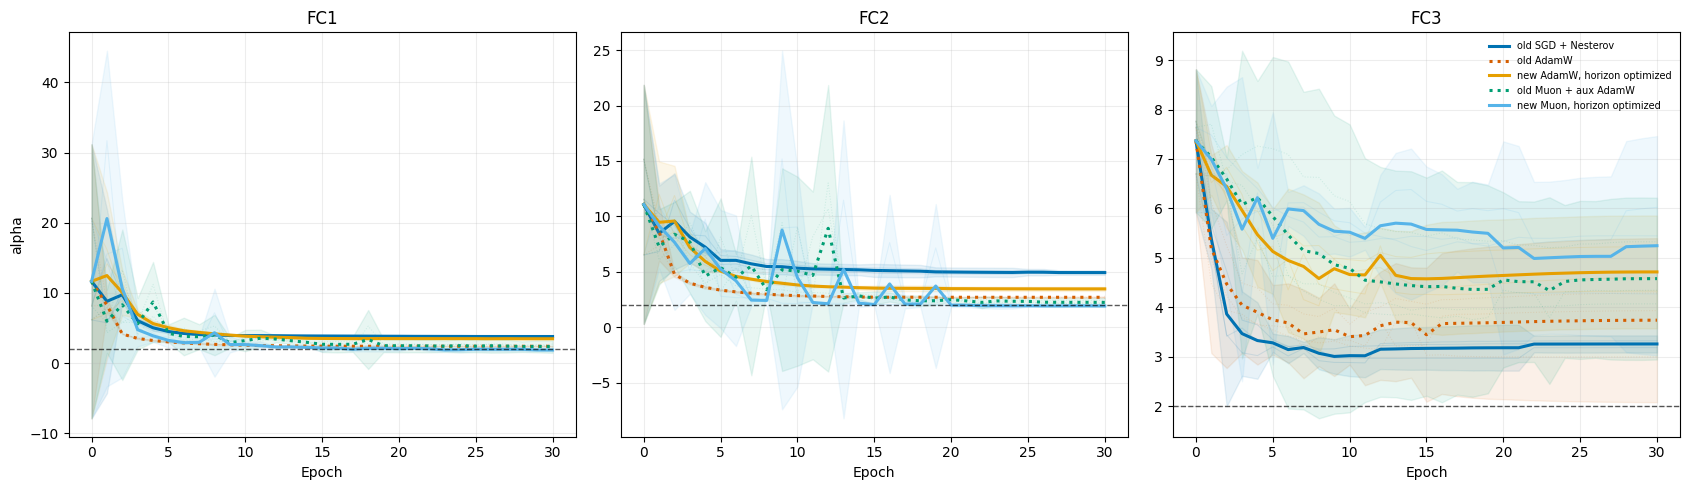

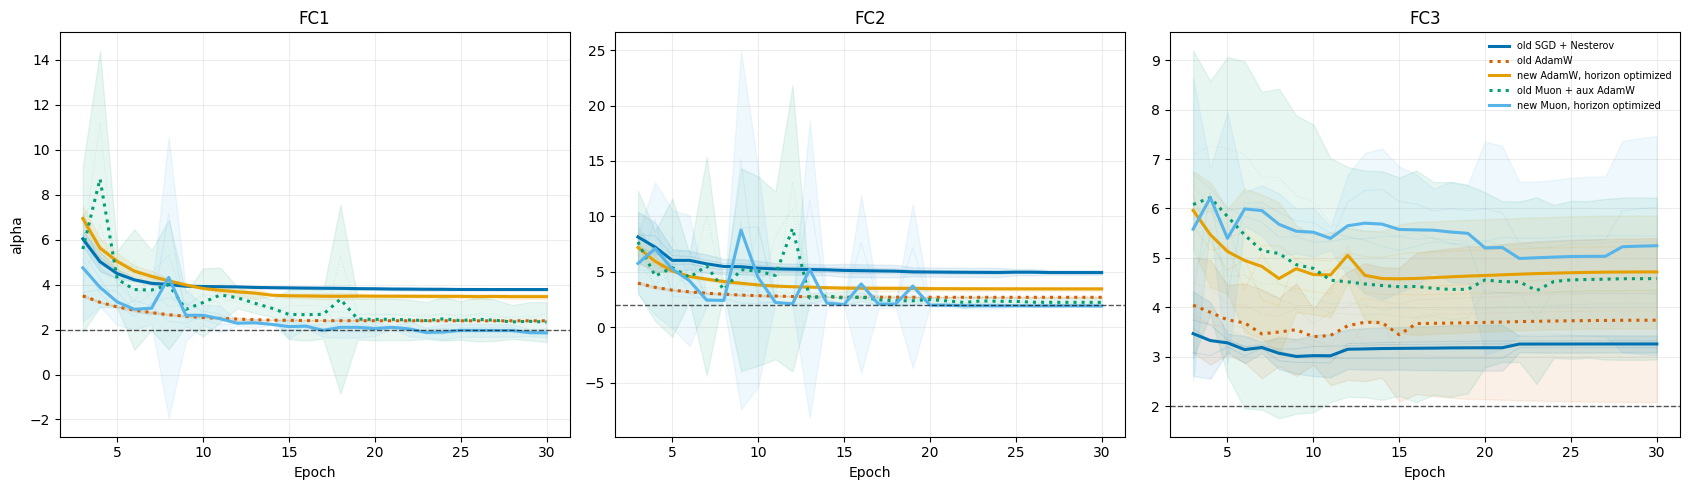

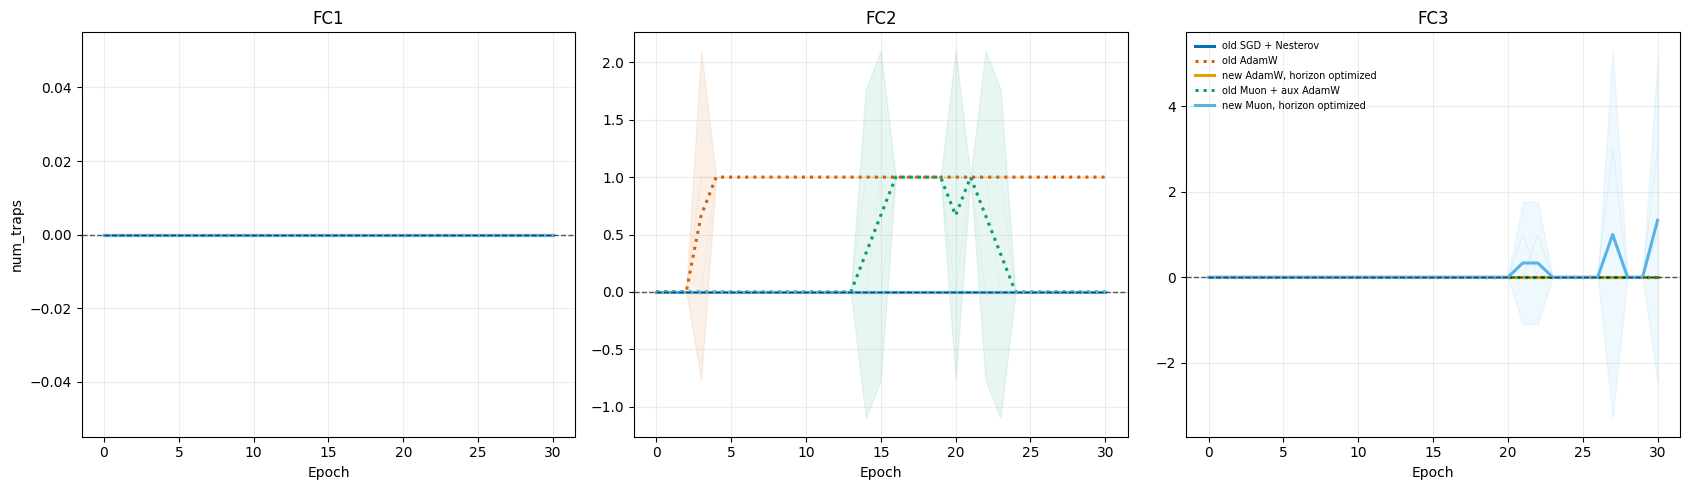

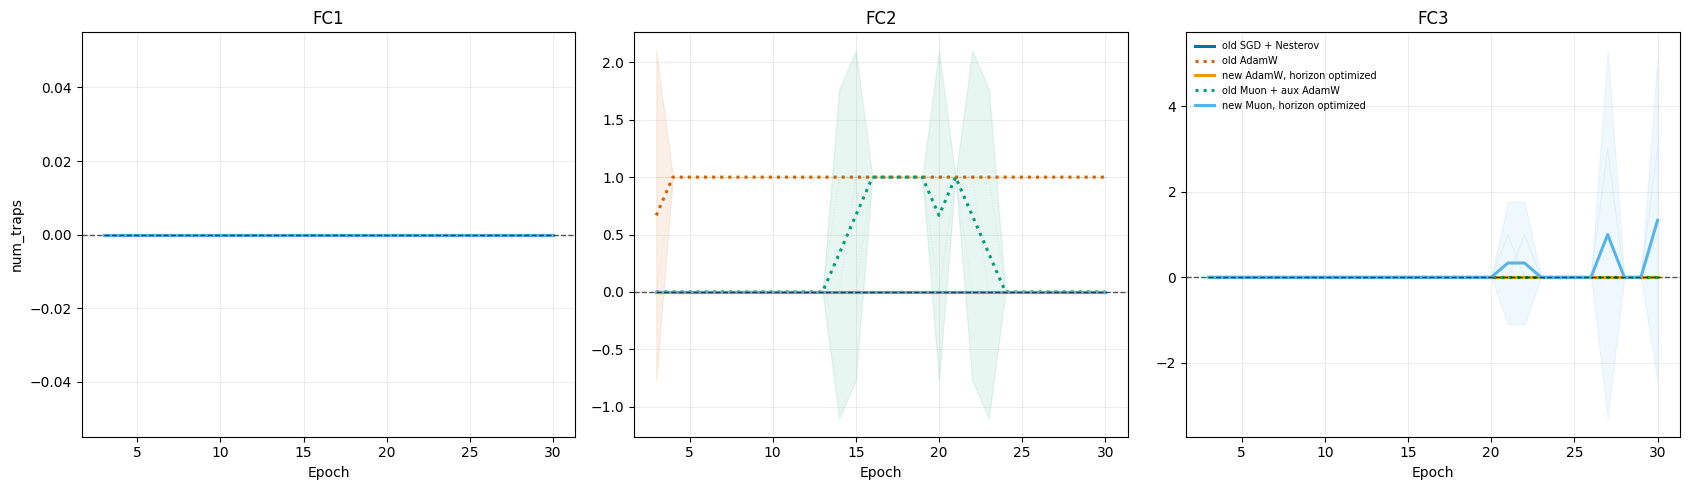

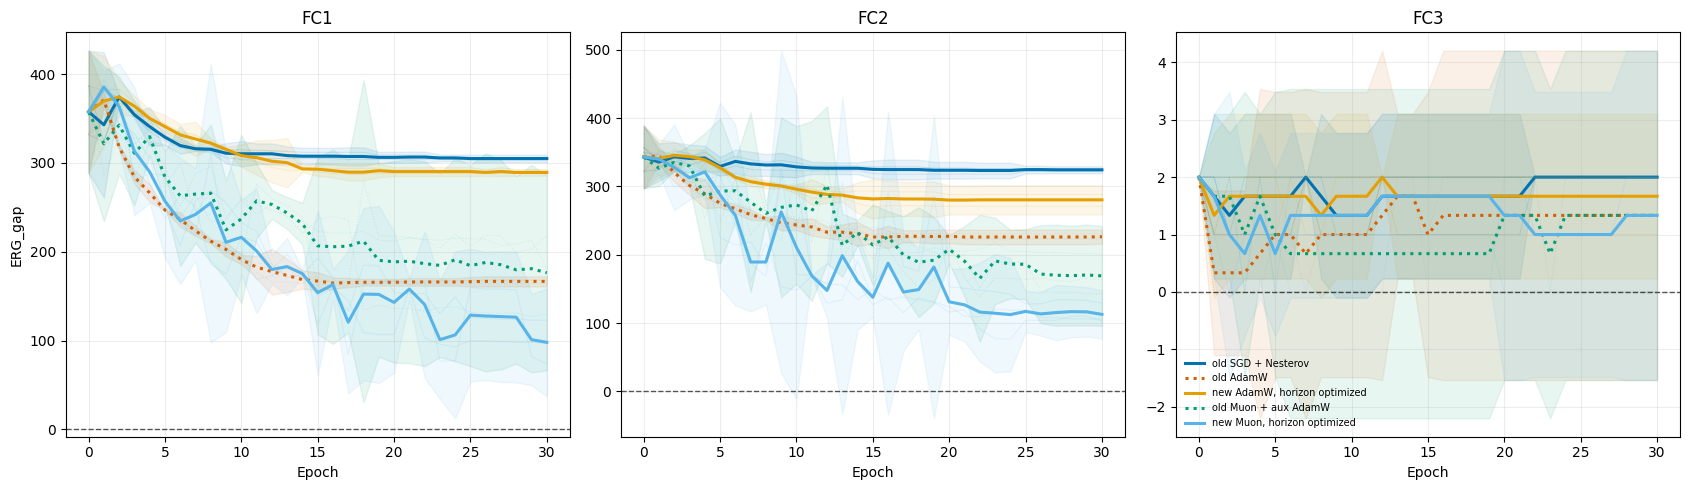

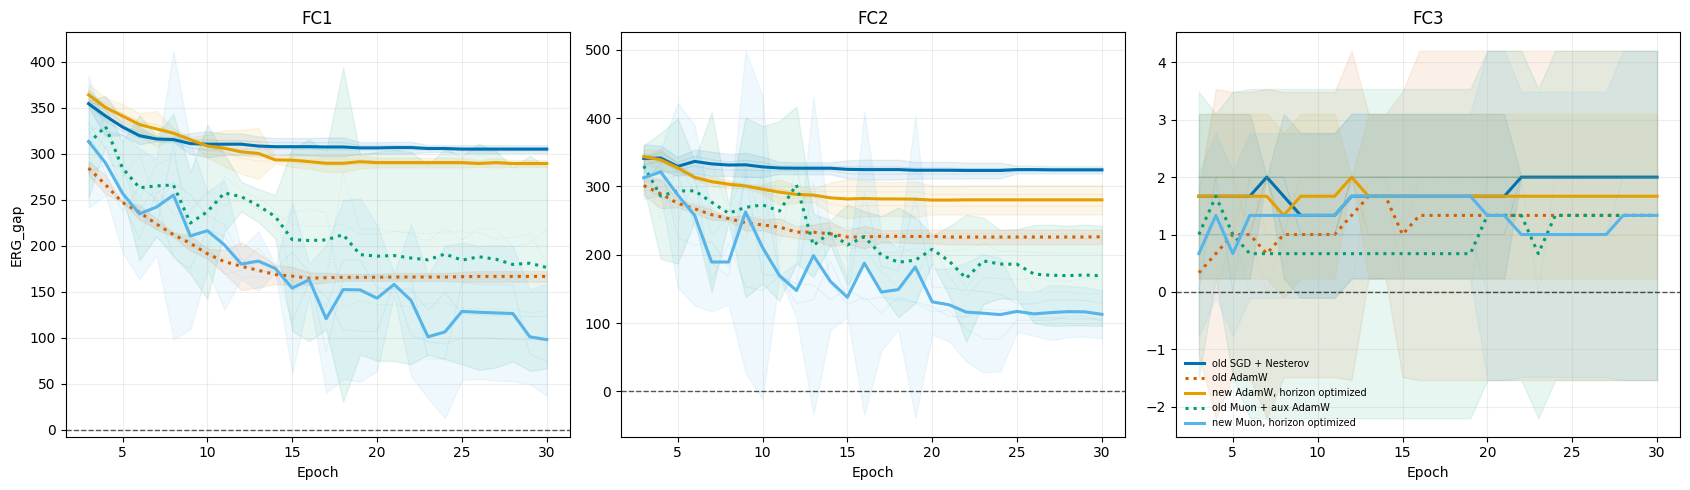

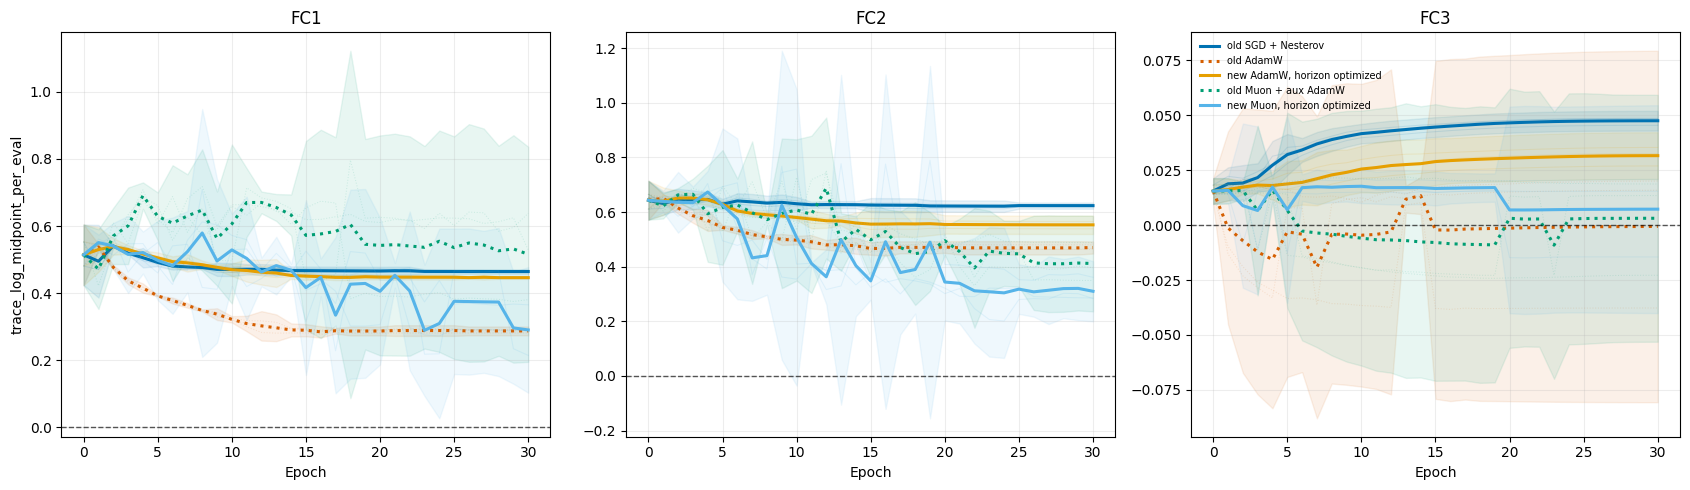

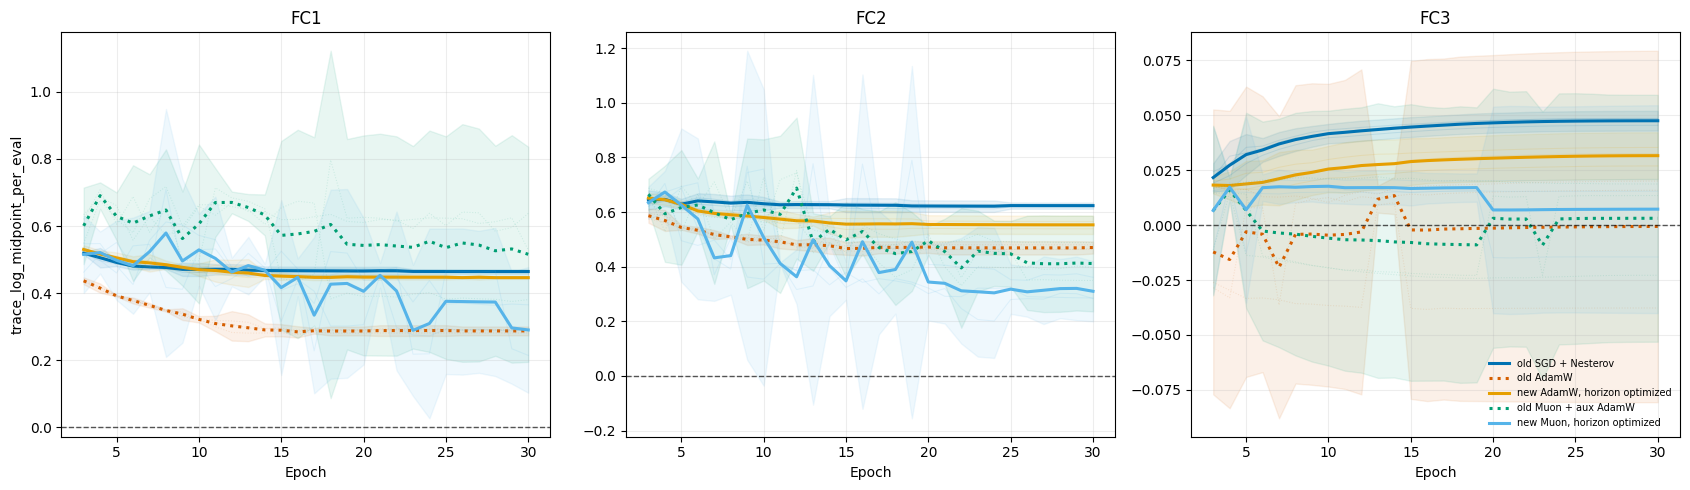

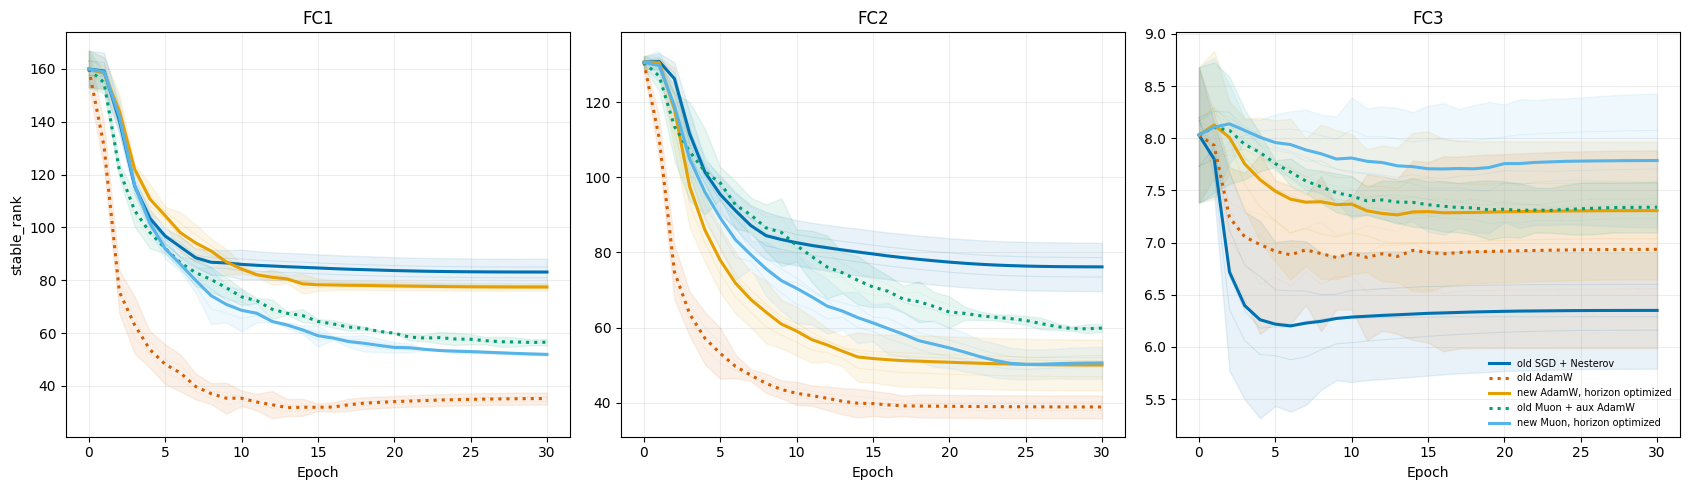

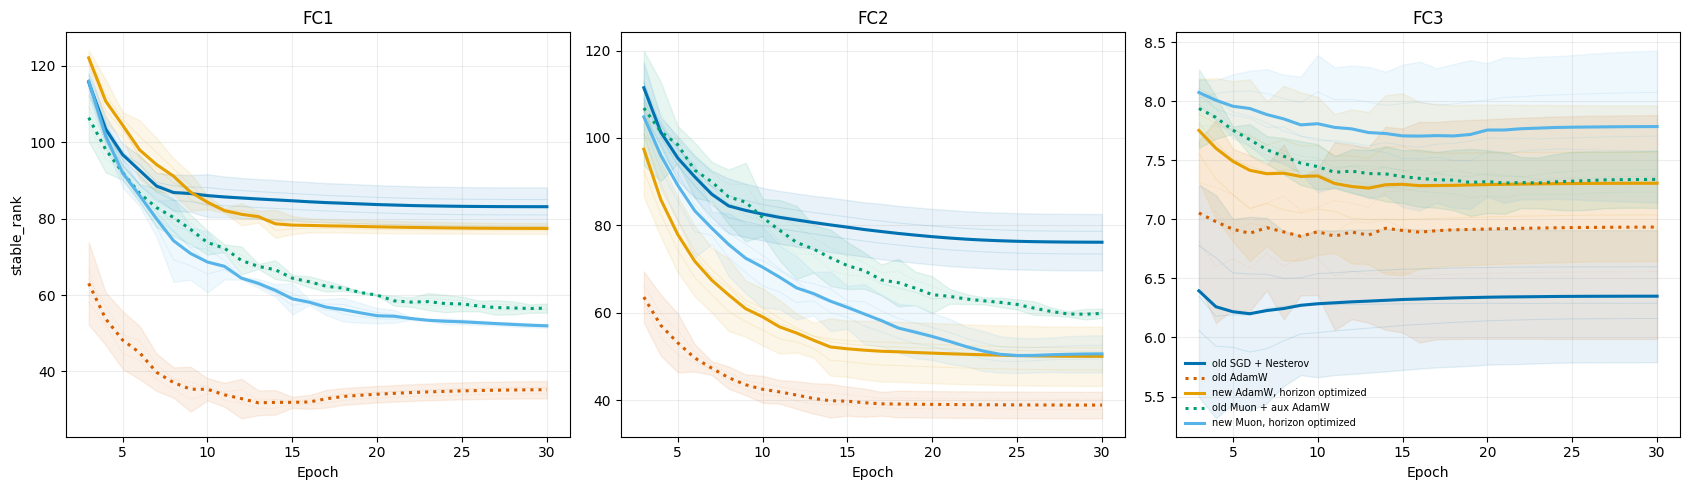

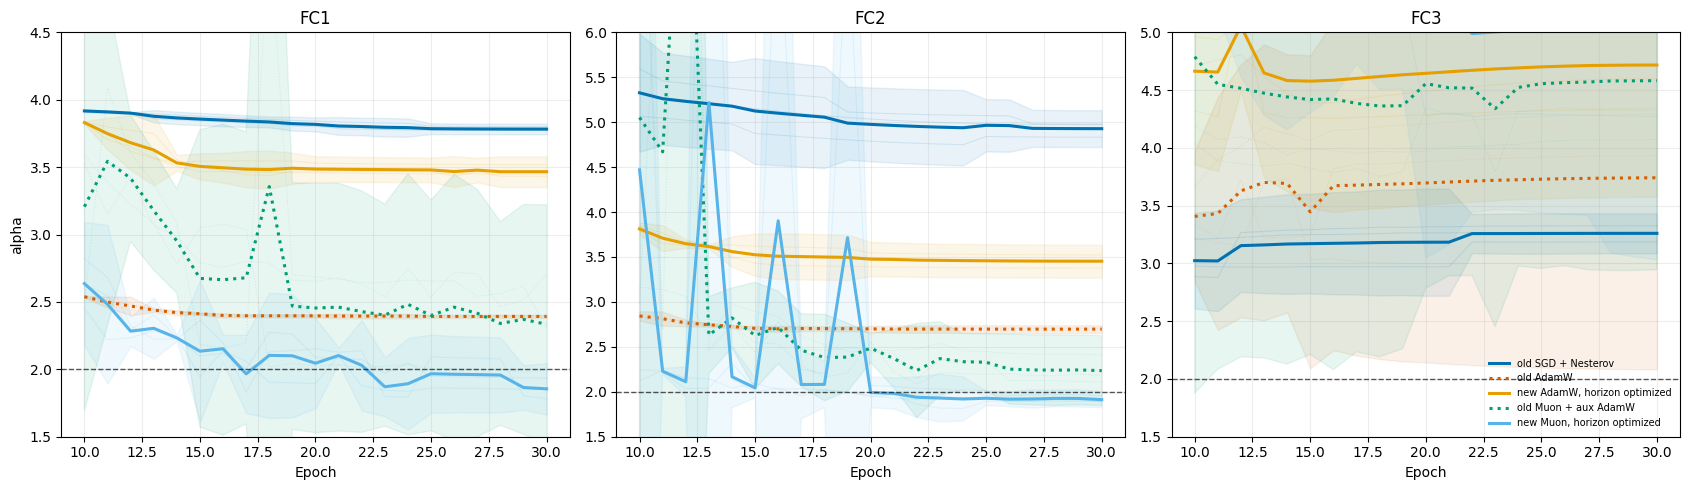

In [7]:
valid = spectral_metrics.loc[spectral_metrics['status'].astype(str).eq('ok')].copy()
SPEC_METRICS = ['alpha', 'num_traps', 'ERG_gap', 'm_midpoint', 'trace_log_midpoint_per_eval', 'stable_rank']
spectral_summary = summarize(valid, ('arm', 'arm_label', 'family', 'variant', 'layer', 'epoch'), SPEC_METRICS)
display(spectral_summary.sort_values(['metric', 'family', 'variant', 'layer', 'epoch']))
def plot_spec(metric, zoom_start=None, ylims=None, ref=None):
    data = valid.copy()
    summary = spectral_summary.copy()
    if zoom_start is not None:
        data = data.loc[data['epoch'].astype(int).ge(zoom_start)]
        summary = summary.loc[summary['epoch'].astype(int).ge(zoom_start)]
    fig, axes = plt.subplots(1, len(LAYER_ORDER), figsize=(17, 5), sharex=True)
    for ax, layer in zip(axes, LAYER_ORDER, strict=True):
        for spec in ARM_SPECS:
            raw = data.loc[data['arm'].eq(spec['arm']) & data['layer'].astype(str).eq(layer)]
            for seed, run in raw.groupby('seed'):
                ax.plot(run['epoch'], run[metric], color=spec['color'], linestyle=spec['linestyle'], linewidth=0.75, alpha=0.12)
            rows = summary.loc[summary['arm'].eq(spec['arm']) & summary['layer'].astype(str).eq(layer) & summary['metric'].eq(metric)].sort_values('epoch')
            if rows.empty:
                continue
            ax.plot(rows['epoch'], rows['mean'], color=spec['color'], linestyle=spec['linestyle'], linewidth=2.2, label=spec['label'])
            ax.fill_between(rows['epoch'], rows['ci_low'], rows['ci_high'], color=spec['color'], alpha=0.09)
        if ref is not None:
            ax.axhline(ref, color='black', linestyle='--', linewidth=1.0, alpha=0.65)
        if ylims and layer in ylims:
            ax.set_ylim(*ylims[layer])
        ax.set(title=layer.upper(), xlabel='Epoch')
        ax.grid(alpha=0.22)
    axes[0].set_ylabel(metric)
    axes[-1].legend(frameon=False, fontsize=7)
    fig.tight_layout()
    out = (ZOOM_DIR if zoom_start is not None else PLOT_DIR) / ((f'zoom_epoch{zoom_start}_' if zoom_start is not None else 'full_') + metric + '.png')
    fig.savefig(out, dpi=180, bbox_inches='tight')
    plt.show()
for metric, ref in [('alpha', 2.0), ('num_traps', 0.0), ('ERG_gap', 0.0), ('trace_log_midpoint_per_eval', 0.0), ('stable_rank', None)]:
    if metric in valid.columns:
        plot_spec(metric, ref=ref)
        plot_spec(metric, zoom_start=3, ref=ref)
plot_spec('alpha', zoom_start=10, ref=2.0, ylims={'fc1': (1.5, 4.5), 'fc2': (1.5, 6.0), 'fc3': (1.5, 5.0)})


In [8]:
def fmt(arm, checkpoint, metric, scale=1.0):
    row = metric_row(terminal_summary, arm, checkpoint, metric)
    return f'{scale * float(row["mean"]):.4f} ± {scale * float(row["ci_half_width"]):.4f}'
lines = ['## Summary', '', '| Arm | Final test acc % | Final test loss | Selected test acc % | Selected test loss |', '|---|---:|---:|---:|---:|']
for arm in ARM_ORDER:
    lines.append(f'| {ARM_LABELS[arm]} | {fmt(arm, "final", "test_accuracy", 100.0)} | {fmt(arm, "final", "test_loss")} | {fmt(arm, "validation_selected", "test_accuracy", 100.0)} | {fmt(arm, "validation_selected", "test_loss")} |')
display(Markdown(chr(10).join(lines)))


## Summary

| Arm | Final test acc % | Final test loss | Selected test acc % | Selected test loss |
|---|---:|---:|---:|---:|
| old SGD + Nesterov | 98.4167 ± 0.1497 | 0.0568 ± 0.0047 | 98.4167 ± 0.1497 | 0.0569 ± 0.0048 |
| old AdamW | 98.5133 ± 0.1004 | 0.0826 ± 0.0108 | 97.9133 ± 0.6330 | 0.0799 ± 0.0196 |
| new AdamW, horizon optimized | 98.4167 ± 0.1518 | 0.0743 ± 0.0063 | 97.9567 ± 0.7865 | 0.0735 ± 0.0148 |
| old Muon + aux AdamW | 98.6333 ± 0.1691 | 0.1234 ± 0.0089 | 97.1733 ± 0.3795 | 0.0920 ± 0.0079 |
| new Muon, horizon optimized | 98.6467 ± 0.1654 | 0.0912 ± 0.0132 | 97.6033 ± 0.6465 | 0.0786 ± 0.0227 |